# Histogram Mode Detector

## TL;DR - Get normalized sample images averaged along the rotation angle.

In [1]:
from ess.ymir.data import ymir_lego_images_path
from ess.ymir.io import FilePath
from ess.ymir.normalize import NormalizedSampleImages
from ess.ymir.workflow import (
    YmirImageNormalizationWorkflow,
    ImageDetectorName,
    RotationMotionSensorName,
)

wf = YmirImageNormalizationWorkflow()
wf[FilePath] = (
    ymir_lego_images_path()
)  # Replace with the path to your images in nexus file.
wf[ImageDetectorName] = 'orca'
wf[RotationMotionSensorName] = 'motion_cabinet_2'
normalized = wf.compute(NormalizedSampleImages)
normalized

/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/io.py:107: UserWarning: The unit of the histogram detector data is [None]. It is expected to be [counts]. The loader manually assigned the unit to be [counts].
  warnings.warn(
/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing average open beam image assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)
/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing average dark current image assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)
/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing average background pixel counts assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)


/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing average sample pixel counts assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)
/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing normalized sample image stack assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)


<scipp.DataArray>
Dimensions: Sizes[time:36, dim_1:256, dim_2:256, ]
Coordinates:
* dim_1                       int64  [dimensionless]  (dim_1)  [0, 1, ..., 254, 255]
* dim_2                       int64  [dimensionless]  (dim_2)  [0, 1, ..., 254, 255]
* rotation_angle            float64            [deg]  (time)  [1.00731, 11.0344, ..., 341.951, 351.979]
* time                    datetime64             [ns]  (time)  [2024-08-14T14:16:57.997255602, 2024-08-14T14:17:46.682255224, ..., 2024-08-14T14:44:41.925222722, 2024-08-14T14:45:30.825154517]
Data:
                            float64  [dimensionless]  (time, dim_1, dim_2)  [1.04763, 1.06166, ..., 0.992304, 0.997319]
Masks:
  counts                       bool        <no unit>  (time, dim_1, dim_2)  [False, False, ..., False, False]

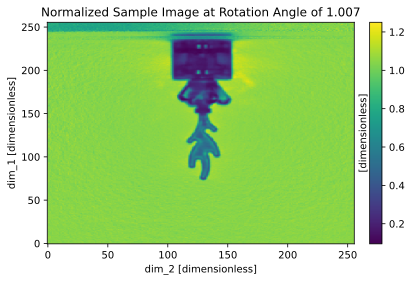

In [2]:
normalized['time', 0].plot(
    title=f'Normalized Sample Image at Rotation Angle of {normalized.coords["rotation_angle"].values[0]:.3f}'
)

You can use a slicer to browse images along the rotation angle.

```python
%matplotlib widget
from plopp import slicer

slicer(normalized)
```

If you want to bin the images by linear steps of angles,
you can use ``sc.groupby`` like below.

```python
%matplotlib widget
import scipp as sc
from plopp import slicer

slicer(normalized.groupby(
    'rotation_angle',
    bins=sc.linspace(dim='rotation_angle', start=-0.5, stop=4.5, num=5, unit='deg'),
).mean('rotation_angle'))
```

## IO

I/O providers can load white beam images and slice them according to the image key.

Unlike ``rotation_angle``, ``image_key`` is not assigned as a coordinate.

Instead, we slice the data according to the ``image_key`` and separate image stacks earlier due to the performance limitation of three-dimensional data binning.

> For example, for 400 images of 2_048 x 2_048 pixels couldn't be done in the regular laptop.

### Load the data as a stack of images

In [3]:
from ess.ymir.data import ymir_lego_images_path
from ess.ymir.io import (
    FilePath,
    SampleImageStacksWithLogs,
    RawSampleImageStacks,
    OpenBeamImageStacks,
    DarkCurrentImageStacks,
    AllImageStacks,
)
from ess.ymir.workflow import (
    YmirImageNormalizationWorkflow,
    ImageDetectorName,
    RotationMotionSensorName,
)

wf = YmirImageNormalizationWorkflow()
wf[FilePath] = ymir_lego_images_path()
wf[ImageDetectorName] = 'orca'
wf[RotationMotionSensorName] = 'motion_cabinet_2'

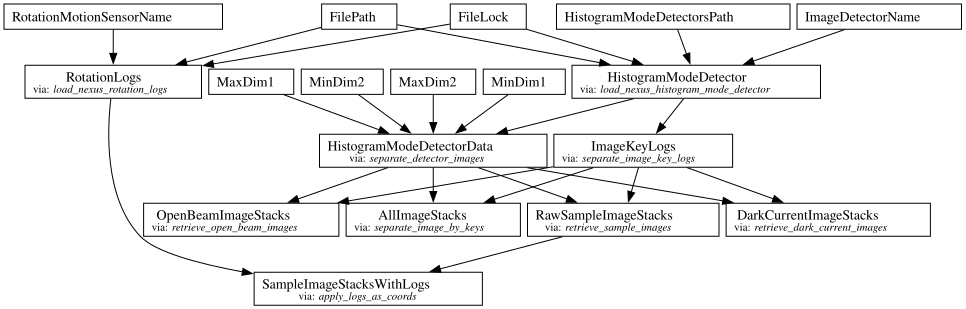

In [4]:
image_stack_types = (
    AllImageStacks,
    RawSampleImageStacks,
    OpenBeamImageStacks,
    DarkCurrentImageStacks,
    SampleImageStacksWithLogs,
)
wf.visualize(image_stack_types)

In [5]:
results = wf.compute(image_stack_types)
results[SampleImageStacksWithLogs]

/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/io.py:107: UserWarning: The unit of the histogram detector data is [None]. It is expected to be [counts]. The loader manually assigned the unit to be [counts].
  warnings.warn(


<scipp.DataArray>
Dimensions: Sizes[time:36, dim_1:256, dim_2:256, ]
Coordinates:
* dim_1                       int64  [dimensionless]  (dim_1)  [0, 1, ..., 254, 255]
* dim_2                       int64  [dimensionless]  (dim_2)  [0, 1, ..., 254, 255]
* rotation_angle            float64            [deg]  (time)  [1.00731, 11.0344, ..., 341.951, 351.979]
* time                    datetime64             [ns]  (time)  [2024-08-14T14:16:57.997255602, 2024-08-14T14:17:46.682255224, ..., 2024-08-14T14:44:41.925222722, 2024-08-14T14:45:30.825154517]
Data:
                              int32         [counts]  (time, dim_1, dim_2)  [950, 1090, ..., 204, 203]

### Save Individual Frames

In [6]:
from ess.ymir.io import export_image_stacks_as_tiff, ImageKey

from pathlib import Path
from tqdm import tqdm


output_dir = Path("images")
export_image_stacks_as_tiff(
    output_dir=output_dir,
    image_stacks=results[AllImageStacks],
    merge_image_by_key=False,
    overwrite=True,
    progress_wrapper=tqdm,
    image_prefix_map={
        ImageKey.SAMPLE: "sample",
        ImageKey.DARK_CURRENT: "dc",
        ImageKey.OPEN_BEAM: "ob",
    },
)

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

100%|██████████| 36/36 [00:00<00:00, 3438.19it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 2855.99it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 2709.85it/s]


100%|██████████| 3/3 [00:00<00:00, 159.49it/s]

In [7]:
sorted(output_dir.iterdir())

[PosixPath('images/dc_0000.tiff'),
 PosixPath('images/dc_0001.tiff'),
 PosixPath('images/dc_0002.tiff'),
 PosixPath('images/dc_0003.tiff'),
 PosixPath('images/dc_0004.tiff'),
 PosixPath('images/ob_0000.tiff'),
 PosixPath('images/ob_0001.tiff'),
 PosixPath('images/ob_0002.tiff'),
 PosixPath('images/ob_0003.tiff'),
 PosixPath('images/ob_0004.tiff'),
 PosixPath('images/sample_0000.tiff'),
 PosixPath('images/sample_0001.tiff'),
 PosixPath('images/sample_0002.tiff'),
 PosixPath('images/sample_0003.tiff'),
 PosixPath('images/sample_0004.tiff'),
 PosixPath('images/sample_0005.tiff'),
 PosixPath('images/sample_0006.tiff'),
 PosixPath('images/sample_0007.tiff'),
 PosixPath('images/sample_0008.tiff'),
 PosixPath('images/sample_0009.tiff'),
 PosixPath('images/sample_0010.tiff'),
 PosixPath('images/sample_0011.tiff'),
 PosixPath('images/sample_0012.tiff'),
 PosixPath('images/sample_0013.tiff'),
 PosixPath('images/sample_0014.tiff'),
 PosixPath('images/sample_0015.tiff'),
 PosixPath('images/sample_

### Save All Frames in One File

In [8]:
from ess.ymir.io import export_image_stacks_as_tiff, ImageKey
from tqdm import tqdm
from pathlib import Path


output_dir = Path("images")
export_image_stacks_as_tiff(
    output_dir=output_dir,
    image_stacks=results[AllImageStacks],
    merge_image_by_key=True,
    overwrite=True,
    progress_wrapper=tqdm,
    image_prefix_map={
        ImageKey.SAMPLE: "sample",
        ImageKey.DARK_CURRENT: "dc",
        ImageKey.OPEN_BEAM: "ob",
    },
)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 890.64it/s]

In [9]:
tuple(output_dir.iterdir())

(PosixPath('images/ob_0000_0005.tiff'),
 PosixPath('images/dc_0000_0005.tiff'),
 PosixPath('images/sample_0000_0036.tiff'))

In [10]:
!rm -rf images

## Normalization

See :attr:ess.imaging.normalize.normalize_sample_images for more details.

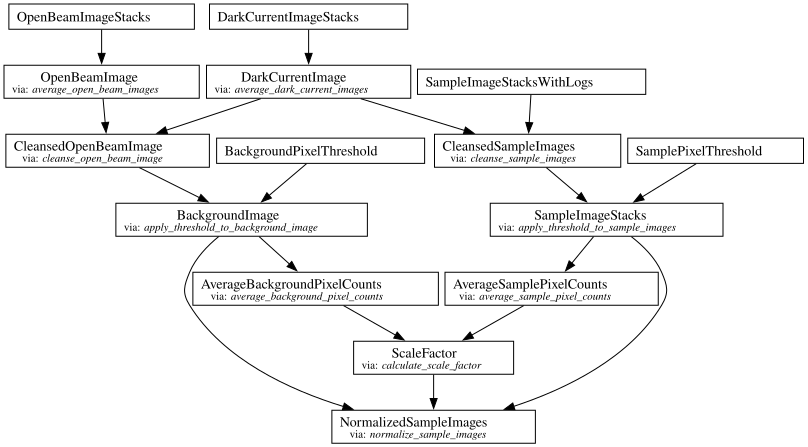

In [11]:
from ess.ymir.normalize import NormalizedSampleImages

wf[OpenBeamImageStacks] = results[OpenBeamImageStacks]
wf[DarkCurrentImageStacks] = results[DarkCurrentImageStacks]
wf[SampleImageStacksWithLogs] = results[SampleImageStacksWithLogs]
wf.visualize(NormalizedSampleImages)

In [12]:
wf.compute(NormalizedSampleImages)

/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing average open beam image assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)
/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing average dark current image assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)
/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing average background pixel counts assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)
/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing average sample pixel counts assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)


/home/runner/work/ess/ess/packages/essimaging/src/ess/ymir/normalize.py:47: UserWarning: Computing normalized sample image stack assuming constant exposure time.
  warnings.warn(warning_message, stacklevel=1)


<scipp.DataArray>
Dimensions: Sizes[time:36, dim_1:256, dim_2:256, ]
Coordinates:
* dim_1                       int64  [dimensionless]  (dim_1)  [0, 1, ..., 254, 255]
* dim_2                       int64  [dimensionless]  (dim_2)  [0, 1, ..., 254, 255]
* rotation_angle            float64            [deg]  (time)  [1.00731, 11.0344, ..., 341.951, 351.979]
* time                    datetime64             [ns]  (time)  [2024-08-14T14:16:57.997255602, 2024-08-14T14:17:46.682255224, ..., 2024-08-14T14:44:41.925222722, 2024-08-14T14:45:30.825154517]
Data:
                            float64  [dimensionless]  (time, dim_1, dim_2)  [1.04763, 1.06166, ..., 0.992304, 0.997319]
Masks:
  counts                       bool        <no unit>  (time, dim_1, dim_2)  [False, False, ..., False, False]